# Hotel booking demand



#### Data Source: https://www.kaggle.com/jessemostipak/hotel-booking-demand

#### Data Description: The data is a record of hotel booking demand. It contains 32 columns and 119390 rows. The columns include information about the booking, the hotel, the customer, and the stay. The data is in a CSV file format.



## Project Overview
In this project, we aim to build a machine learning model to predict whether a hotel booking will be canceled (`is_canceled`). This prediction is crucial for hotels to manage resources efficiently and optimize revenue. By accurately predicting cancellations, hotels can take proactive measures such as overbooking or offering promotions to minimize the impact of cancellations.

**Data Loading and Exploration:(EDA)**
    - Load the dataset and explore its structure and contents.
    - Understand the features and target variable.

**Data Preprocessing:**
    - Handle missing values and outliers.
    - Encode categorical variables.
    - Normalize or scale numerical features if necessary.

**Feature Selection:**
    - Select relevant features that contribute to the prediction of cancellations.
    - Split the data into features (`X`) and target variable (`y`).

**Data Splitting:**
    - Split the data into training and testing sets to evaluate the models performance.

**Model Building:**
    - Choose appropriate machine learning algorithms.
    - Train the model using the training data.
    - Tune hyperparameters to improve model performance.

**Model Evaluation:**
    - Evaluate the model using the testing data.
    - Use metrics such as accuracy, precision, recall, and F1-score to assess the models performance.

**Model Interpretation:**
    - Interpret the models predictions and understand the importance of different features.
    - Visualize the results and insights gained from the model.

**Deployment:**
    - Deploy the model for real-time prediction if required.
    - Create a user interface or API for easy access to the models predictions.

By following these steps, we aim to develop a robust model that can help hotels make data-driven decisions to optimize their operations and minimize the impact of booking cancellations.


### Target
The target variable in this dataset is the `is_canceled` column. This column indicates whether a hotel booking was canceled or not. It is a binary variable with the following possible values:

- `0`: The booking was not canceled.
- `1`: The booking was canceled.

In [20]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline
import numpy as np

In [21]:

# Load the data
df = pd.read_csv('hotel_bookings.csv')

# Display the first few rows of the dataframe
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
#info about the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [23]:
# Divide the features into numerical and categorical types
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()


print("Numerical Features (Total: {}):".format(len(numerical_features)))
print(numerical_features)
print("\nCategorical Features (Total: {}):".format(len(categorical_features)))
print(categorical_features)

Numerical Features (Total: 20):
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Features (Total: 12):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


44224 Canceled (37.04%)
75166 Not Canceled (62.96%)


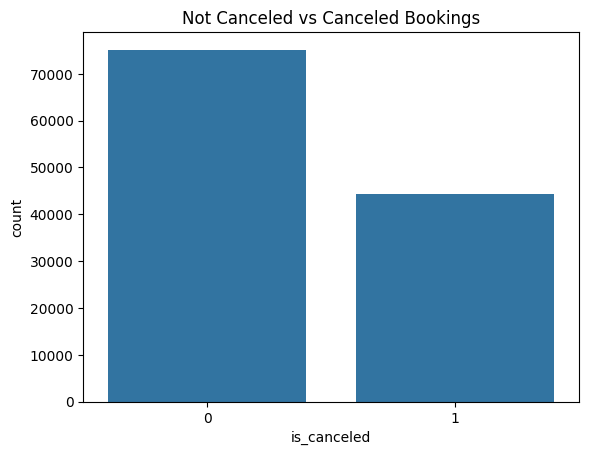

In [32]:
# Calculate the number of canceled and not canceled bookings
canceled = len(df[df["is_canceled"] == 1])
not_canceled = len(df[df["is_canceled"] == 0])
total = len(df)

# Print the counts and percentages
print(f"{canceled} Canceled ({round(canceled / total * 100, 2)}%)")
print(f"{not_canceled} Not Canceled ({round(not_canceled / total * 100, 2)}%)")

# Plot the count of canceled vs not canceled bookings
sns.countplot(data=df, x="is_canceled")
plt.title("Not Canceled vs Canceled Bookings")
plt.show()

In [35]:
from pandas_profiling import ProfileReport
design_report = ProfileReport(df)
design_report.to_file(output_file='Hotel_Booking_Auto.html')

C:\Users\eitank\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PydanticImportError: `BaseSettings` has been moved to the `pydantic-settings` package. See https://docs.pydantic.dev/2.10/migration/#basesettings-has-moved-to-pydantic-settings for more details.

For further information visit https://errors.pydantic.dev/2.10/u/import-error

In [ ]:

# Check for missing values in the dataset
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values_percentage = missing_values / len(df) * 100

missing_values_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_values_percentage
})

missing_values_df.sort_values(by='Missing Values', ascending=False)



,Missing Values,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
